# Práctica 2 sobre diferenciación

## Polinomio de Taylor
El comando `taylor(f(x), x, x0, n)` permite contruir el polinomio de Talor de la función $f(x)$ en torno a $x_0$ de grado $n$. El resultado es una expresión simbólica.

In [14]:
f  = lambda x: 1/x
x0 = 1
n  = 4
T(x) = taylor(f(x), x, x0, n)
T

x |--> (x - 1)^4 - (x - 1)^3 + (x - 1)^2 - x + 2

Podemos calcular el error absoluto entre la función y el polinomio en un punto, por ejemplo, $x_1=\frac{1}{2}$.

In [15]:
x1 = 1/2
abs(f(x1) - T(x1))

1/16

O representar dicho error en un intervalo, por ejemplo, $[\frac{1}{5},2]$.

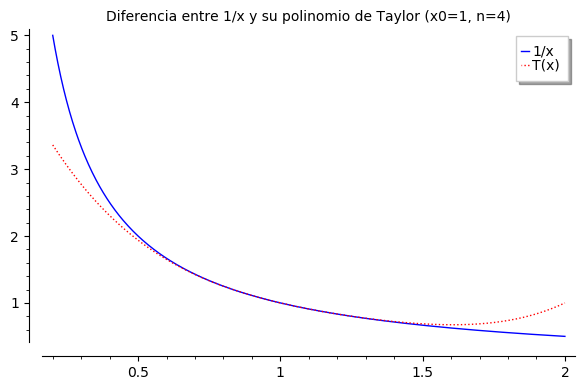

In [21]:
a = 1/5; b = 2
g1 = plot(f(x), a, b, legend_label='1/x')
g2 = plot(T(x), a, b, legend_label='T(x)',linestyle=':', rgbcolor='red')
show(g1+g2, title = 'Diferencia entre 1/x y su polinomio de Taylor (x0=1, n=4)')

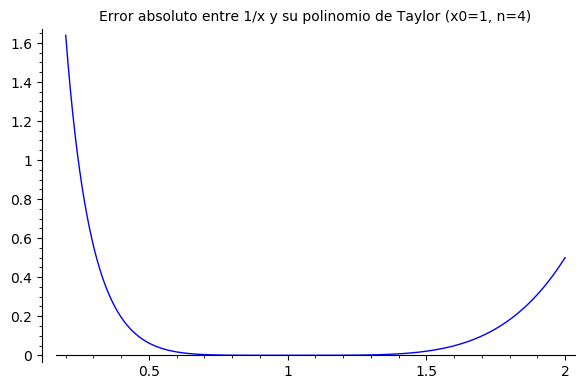

In [22]:
g3 = plot(abs(f(x)-T(x)), a, b)
show(g3, title = 'Error absoluto entre 1/x y su polinomio de Taylor (x0=1, n=4)')

Usando escala logarítmica en el eje OY podemos ver mejor la reducción del error en torno a $x_0$.

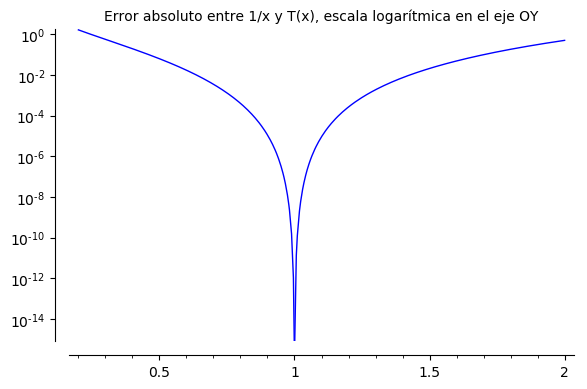

In [38]:
g4 = plot(abs(f(x)-T(x)), a, 1-1e-3, scale="semilogy")
g5 = plot(abs(f(x)-T(x)), 1+1e-3, b, scale="semilogy")
show(g4+g5, title='Error absoluto entre 1/x y T(x), escala logarítmica en el eje OY')

## Derivación numérica
Podemos calcular la derivada aproximada de una función con la regla de 2 puntos hacia adelante.

In [4]:
# función de ejemplo
f = lambda x: -x*sin(x^2) 

# regla de 2 puntos hacia adelante
d1 = lambda x,h: RDF((f(x+h) - f(x))/h) 

# aproximación de la derivada en x0=1, h = 1e-15
d1(1,1e-5) 

-1.9220749758678721

A efectos de comprobación, calculamos la derivada exacta con el comando de cálculo simbólico `diff`. 

Antes de usar una variable simbólica, por ejemplo `x`, debe declarase como tal con `var('x')`. Las expresiones simbólicas, como lo es una derivada, se escriben con la sintaxis: 

`"función ( variables ) = expresión"`

In [3]:
var('x')
df(x) = diff(f(x), x)
df

x |--> -2*x^2*cos(x^2) - sin(x^2)

### Error para $h$ fijo
Ahora mostraremos la diferencia entre la derivada exacta y la aproximada para $x\in [0,\pi]$. Primero construímos una lista con 31 abscisas igualmente espaciadas en $[0,\pi]$.

In [128]:
xi = [0, pi/30 .. pi] # abscisas en [0, pi]

Para un $h$ fijo, calculamos la lista de derivadas aproximadas en las abcisas.

In [129]:
h  = 1e-5 # h fijo
di = list(map(lambda x: d1(x,h), xi)) #ordenadas: derivada numerica en xi

Finalmente, comparamos graficamente la derivada exacta con aproximada.

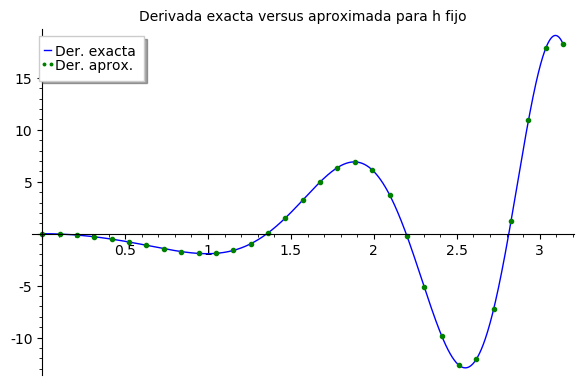

In [130]:
A = plot(df(x), 0, pi, legend_label="Der. exacta")
B = line(zip(xi,di),   legend_label="Der. aprox.", linestyle='', marker = '.', color = 'green')
show(A+B, title='Derivada exacta versus aproximada para h fijo')

### Error para $x$ fijo
Dado un punto $x_0 = 1$, nos preguntamos qué valor de $h$ nos dará la mejor aproximación. Primero calculamos una lista de valores para $h$, desde $10^{-11}$ hasta $10^{-1}$.

In [131]:
hi = list(map(lambda n: RDF(10^n), [-11 .. -1]))
hi

[1e-11, 1e-10, 1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1]

Ahora evaluamos en $x_0$, para cada valor de $h$, la diferencia entre la regla de derivacion numérica y la derivada exacta.

In [133]:
x0 = 1
ei = list(map(lambda h: abs(d1(x0,h) - df(x0)), hi))

Ahora pintamos, en escala logarítmica, el error frente al valor de $h$.

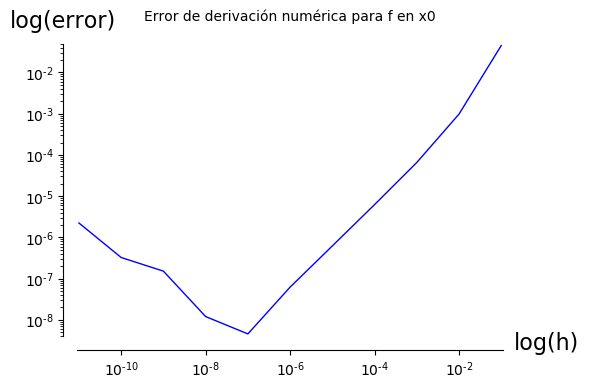

In [134]:
A = line(zip(hi,ei), scale="loglog")
show(A, title='Error de derivación numérica para f en x0', axes_labels=['log(h)', 'log(error)'])

Como se ve, hay un $h$ óptimo que nos da el error mínimo. En este caso $h\approx10^{-7}$. Este valor óptimo cambiará según la función, el punto $x_0$, la regla de derivación , ...

### Orden de convergencia
También podemos ver que, para $h$ superiores (y cercanos) al óptimo, el orden de convergencia es el esperado:

$\left| f'(x) - \dfrac{f(x+h)-f(x)}{h}\right|=O(h).$

Para ello, pintamos la línea $(h,h)$ para comparar. Tendremos que se da el orden $O(h)$ si ambas son (aproximadamente) paralelas.

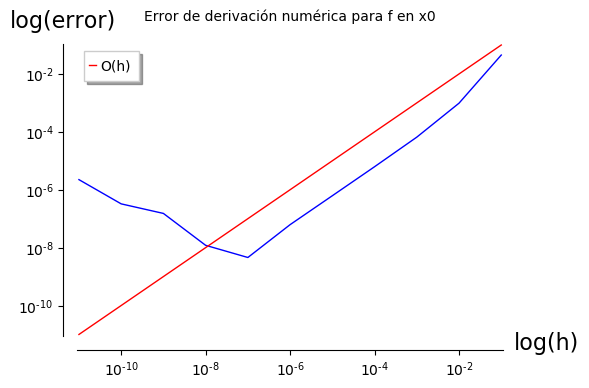

In [135]:
B = line(zip(hi,hi), scale="loglog", legend_label='O(h)', color='red')
show(A+B, title='Error de derivación numérica para f en x0', axes_labels=['log(h)', 'log(error)'])

La razón por la que la derivada numérica deja de converger con orden $O(h)$ es la acumulación del error numérico para $h$ próximos a cero.

**Ejercicio:**

La fórmula de derivación centrada tiene un orden de convergencia mejor que la anterior:

$\left| f'(x) - \dfrac{f(x+h)-f(x-h)}{2h}\right|=O(h^2).$

1. Define una fórmula de derivación centrada.
2. Para un $h$ fijo, repite la gráfica de la diferencia entre la derivada exacta y la aproximada para $x\in [0,\pi]$. ¿qué tal es la aproximación a simple vista?
3. Para un $x_0$ fijo, repite la gráfica de la diferencia entre derivada exacta y la aproximada para $h\in [10^{-11},10^{-1}]$. ¿Para qué $h$ se obtiene el error óptimo?
4. Incluye en la gráfica anterior la línea $(h, h^2)$ para comparar con el orden esperado de convergencia. ¿Para qué intervalo de $h$ se da el orden esperado?

In [136]:
d1 = lambda x,h: RDF((f(x+h) - f(x-h))/(2*h)) # regla de 2 puntos centrada

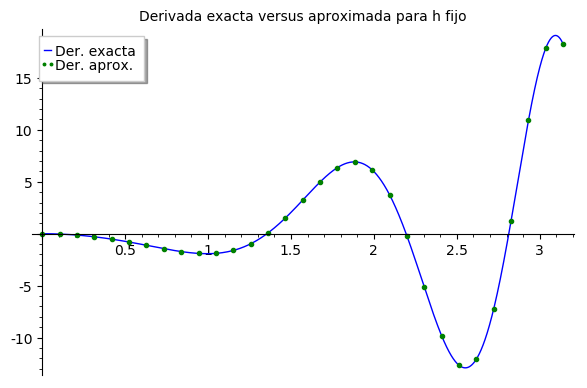

In [137]:
xi = [0, pi/30 .. pi] # abscisas en [0, pi]
h  = 1e-5             # h fijo
di = list(map(lambda x: d1(x,h), xi)) #ordenadas: derivada numerica en xi
A  = plot(df(x), 0, pi, legend_label="Der. exacta")
B  = line(zip(xi,di),   legend_label="Der. aprox.", linestyle='', marker = '.', color = 'green')
show(A+B, title='Derivada exacta versus aproximada para h fijo')

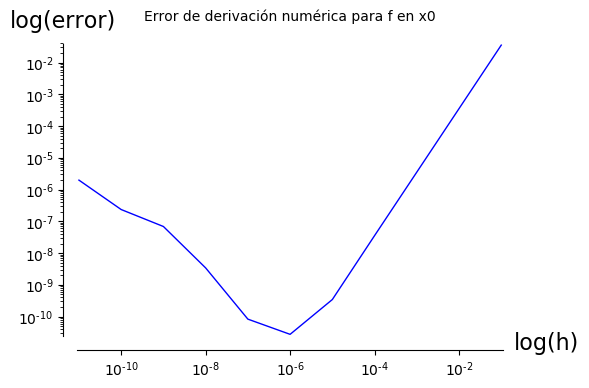

In [138]:
hi = list(map(lambda n: RDF(10^n), [-11 .. -1]))
x0 = RDF(1)
ei = list(map(lambda h: abs(d1(x0,h) - df(x0)), hi))
A = line(zip(hi,ei), scale="loglog")
show(A, title='Error de derivación numérica para f en x0', axes_labels=['log(h)', 'log(error)'])

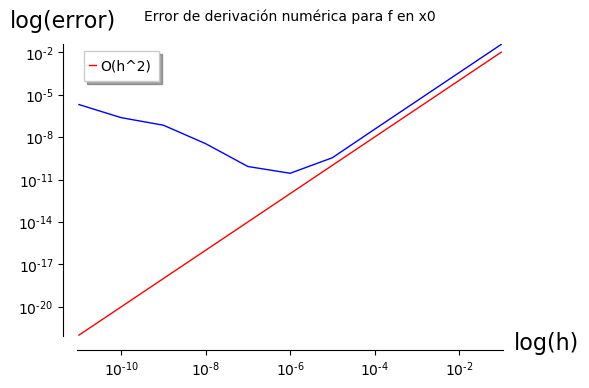

In [139]:
hi2 = list(map(lambda x: x^2, hi))
B = line(zip(hi,hi2), scale="loglog", legend_label='O(h^2)', color='red')
show(A+B, title='Error de derivación numérica para f en x0', axes_labels=['log(h)', 'log(error)'])

## Ideas
- Quitar ejercicio de cálculo de derivadas exactas, indicado a continuación.

In [2]:
f = lambda x: x^4
var('x')              # las variables deben declarase como simbólicas antes del cálculo
df(x) = diff(f(x), x) # las expresiones simbólicas se escriben como: "f(variables) = expresión"
df(2)                 # 4*(x=2)^3 = 32 

32

Podemos calcular derivadas exactas de orden superior.

In [3]:
diff(f(x), x, 2) # derivada segunda

12*x^2

**Ejercicio 1:** calcula las derivadas exactas de las siguientes funciones.
1. $f(x) = \displaystyle  \sqrt{3x} + \sqrt[3]{x}+\frac{1}{x}$.
2. $g(x) = \displaystyle \arctan\left(\frac{x \sin(x)}{1-x\cos(x)}\right)$

In [8]:
f = lambda x: sqrt(3*x) + x^(1/3) + 1/x
var('x')
diff(f(x), x)

1/2*sqrt(3)/sqrt(x) + 1/3/x^(2/3) - 1/x^2

In [9]:
g = lambda x: atan(x*sin(x)/(1-x*cos(x)))
diff(g(x), x)

-(x*cos(x)/(x*cos(x) - 1) + (x*sin(x) - cos(x))*x*sin(x)/(x*cos(x) - 1)^2 + sin(x)/(x*cos(x) - 1))/(x^2*sin(x)^2/(x*cos(x) - 1)^2 + 1)